# Color Enhancement Methods


## Color Enhancement based method

1.**Gamma Correction:** Adjusts the brightness of an image by transforming pixel values using a gamma value.


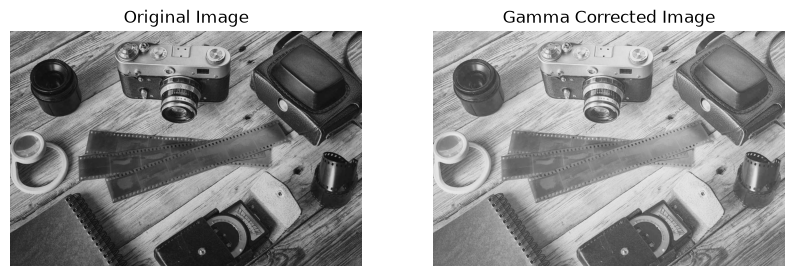

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def gamma_correction(image, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array(
        [((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]
    ).astype("uint8")
    return cv2.LUT(image, table)


image = cv2.imread("../images/samplecamera.jpg")
gamma_corrected = gamma_correction(image, gamma=2.0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Gamma Corrected Image")
plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

## Histogram-Based Methods

**Contrast-Limited Adaptive Histogram Equalization (CLAHE):** Enhances contrast in small regions of the image.


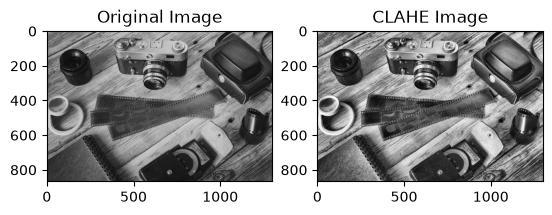

In [ ]:
def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if image is not None:
        if len(image.shape) == 2:
            return clahe.apply(image)
        elif len(image.shape) == 3:
            channels = cv2.split(image)
            clahe_channels = [clahe.apply(ch) for ch in channels]
            return cv2.merge(clahe_channels)
    else:
        return None


image_path = cv2.imread("../images/samplecamera.jpg")

image = cv2.imread("../images/samplecamera.jpg", 0)
clahe_image = clahe(image)

if clahe_image is not None:
    plt.Figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap="gray")

    plt.subplot(1, 2, 2)
    plt.title("CLAHE Image")
    plt.imshow(clahe_image, cmap="gray")
    plt.show()
else:
    print("Failed to load or apply CLAHE")

# `Spatial Filtering`


**Averaging Filter:** Smooths an image by replacing each pixel's value with the average of its neighboring pixels


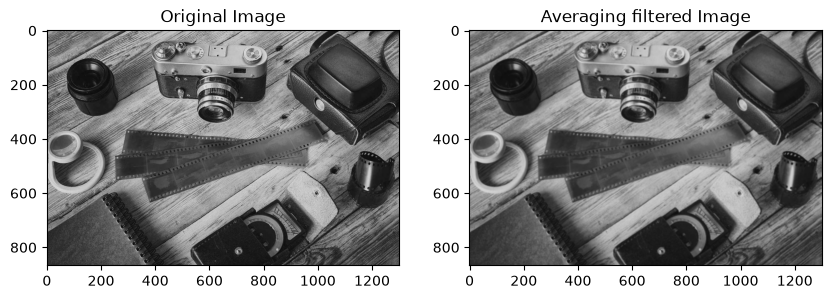

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread("../images/samplecamera.jpg")

avg = cv.blur(image, (5, 5))

# Display the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title("Averaging filtered Image")
plt.imshow(cv.cvtColor(avg, cv.COLOR_BGR2RGB))
plt.show()

## Image Noise


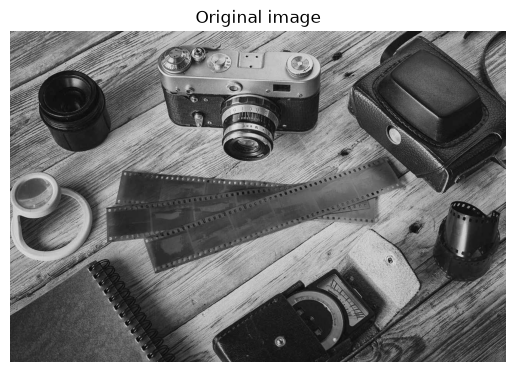

In [ ]:
img = np.array(image)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original image")
plt.axis("off")
plt.show()

Adding Gaussian Noise


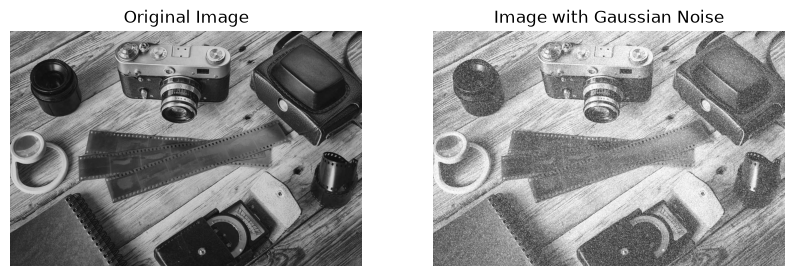

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def add_gaussian_noise(image, mean=0, sigma=25):
    """
    Add Gaussian noise to an image.

    Parameters:
    - image: The input image to which noise is added.
    - mean: The mean of the Gaussian distribution .
    - sigma: The standard deviation of the Gaussian distribution .

    Returns:
    - noisy_image: The image with added Gaussian noise.
    """
    # Generate Gaussian noise
    gaussian_noise = np.random.normal(mean, sigma, image.shape).astype("uint8")

    # Add the noise to the original image
    noisy_image = cv2.add(image, gaussian_noise)

    return noisy_image


# Load image in grayscale
image = cv2.imread("../images/samplecamera.jpg", cv2.IMREAD_GRAYSCALE)

# Add Gaussian noise to the image
noisy_image = add_gaussian_noise(image, mean=40, sigma=30)

# Display input and output images side by side
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")
plt.axis("off")  # Hide axes for cleaner display
plt.subplot(1, 2, 2)
plt.title("Image with Gaussian Noise")
plt.imshow(noisy_image, cmap="gray")
plt.axis("off")  # Hide axes for cleaner display
plt.show()

# Morphological Operation


`Erosion` and `Dilation`


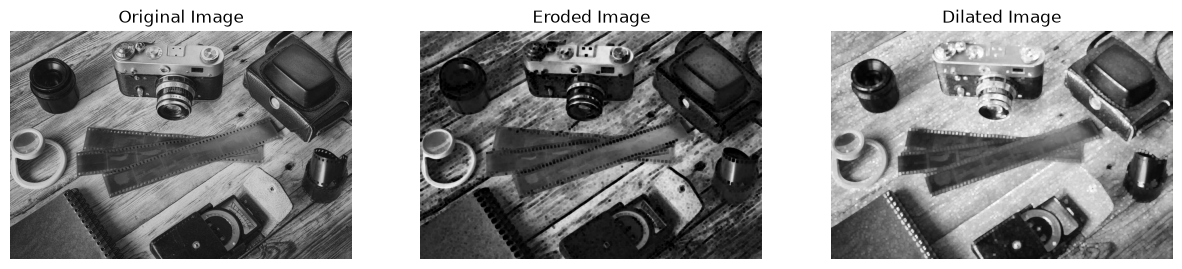

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../images/samplecamera.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None, "File could not be read"

# Define the kernel
kernel = np.ones((7, 7), np.uint8)

# Perform all morphological operations
erosion = cv.erode(img, kernel, iterations=1)
dilation = cv.dilate(img, kernel, iterations=1)

# Display all the images side by side
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Eroded image
plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Eroded Image")
plt.axis("off")

# Dilated image
plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilated Image")
plt.axis("off")

# Show the images
plt.show()

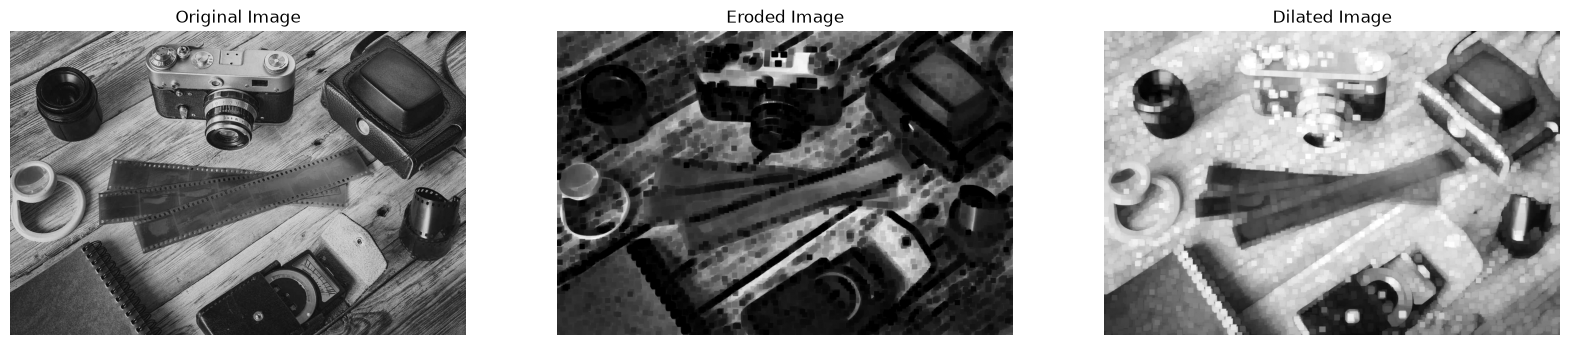

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../images/samplecamera.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None, "File could not be read"

# Define the kernel
kernel = np.ones((15, 15), np.uint8)

# Perform all morphological operations
erosion = cv.erode(img, kernel, iterations=1)
dilation = cv.dilate(img, kernel, iterations=1)

# Display all the images side by side
plt.figure(figsize=(20, 20))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Eroded image
plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Eroded Image")
plt.axis("off")

# Dilated image
plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilated Image")
plt.axis("off")

# Show the images
plt.show()

`Opening` and `Closing`
